In [1]:
from astropy.io import fits
import pyregion
import numpy as np
import matplotlib.pyplot as plt
from astropy import units as u
from astropy import constants as cte 
import regions
from astropy.nddata import Cutout2D
from astropy.coordinates import Angle
from astropy.table import QTable, Table
from astropy.coordinates import SkyCoord
from astropy.modeling import models, fitting
from astropy.modeling.models import Const1D
FITTER = fitting.LevMarLSQFitter()
from discrete_gaussian_model import DiscreteGaussianModel

First, we call the data with the mean spectrum of the three regions. The files are called 'Lambda_NIRSpec_region1.ecsv' and 'Flux_NIRSpec_Region1.ecsv'. Lambda is for the wavelengths (in microns) and Flux is for the flux (in MJy/sr). If we want to check another region, just change the number.

In [2]:
Lamb = QTable.read('Lambda_NIRSpec_Region1.ecsv')
Lamb

N_1,N_2,N_3
um,um,um
float64[3610],float64[3915],float64[3814]
2.8703323855588674 .. 5.270317384012739,0.0 .. 0.0,0.0 .. 0.0
0.0 .. 0.0,0.9701175286099896 .. 1.88990752673271,0.0 .. 0.0
0.0 .. 0.0,0.0 .. 0.0,1.6601979666156694 .. 3.170145922922529


In [3]:
Flux = QTable.read('Flux_NIRSpec_Region1.ecsv')
Flux

N_1,N_2,N_3
MJy / sr,MJy / sr,MJy / sr
float32[3610],float32[3915],float32[3814]
22.962223052978516 .. 99.76720428466797,0.0 .. 0.0,0.0 .. 0.0
0.0 .. 0.0,7.746485233306885 .. 12.545706748962402,0.0 .. 0.0
0.0 .. 0.0,0.0 .. 0.0,8.681315422058105 .. nan


If we want to compare the F187N filter with the spectrum, in this case we will use the column 'N_3'. Both have units: microns for wavelength and MJy/sr for flux.

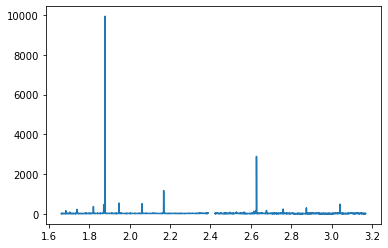

In [4]:
plt.plot(Lamb['N_3'][2].value,Flux['N_3'][2].value)
plt.show()

Now I found the index to cut the spectrum and have only the same wavelength range as the F187N filter.

In [5]:
idx_l = 0
while Lamb['N_3'][2][idx_l].value < 1.7482:
    idx_l = idx_l + 1
idx_r = 0
while Lamb['N_3'][2][idx_r].value < 2.0022:
    idx_r = idx_r + 1

print(idx_l,idx_r)

223 864


And cut the spectrum

In [6]:
x = Lamb['N_3'][2][idx_l:idx_r] # This is lambda
y = Flux['N_3'][2][idx_l:idx_r] # This is the flux

# Model

Now for the model, I need to restrict the initial values.

For the bin_width I used the wavelength step.

I have been changing the parameters.

In [7]:
def fit_to_spec(lamb, flu):
    g0 = DiscreteGaussianModel(
        amplitude=500.0, mean=1.817, stddev=0.00025, 
        bin_width=0.000396, fixed={"bin_width": True},
        )
    g0.mean.bounds = 1.819, 1.82
    g0.stddev.bounds = 0.00001, 0.0003
    g0.amplitude.bounds = 200, 600.0

    g1 = DiscreteGaussianModel(
        amplitude=500.0, mean=1.869, stddev=0.00025,
        bin_width=0.000396, fixed={"bin_width": True},
        )
    g1.mean.bounds = 1.8705, 1.872
    g1.stddev.bounds = 0.00001, 0.0003
    g1.amplitude.bounds = 200.0, 600.0
    
    g2 = DiscreteGaussianModel(
        amplitude=11000.0, mean=1.875, stddev=0.00025,
        bin_width=0.000396, fixed={"bin_width": True},
        )
    g2.mean.bounds = 1.8771, 1.878
    g2.stddev.bounds = 0.0001, 0.0003
    g2.amplitude.bounds = 11000.0, 15000.0
    
    g3 = DiscreteGaussianModel(
        amplitude=500.0, mean=1.944, stddev=0.00025,
        bin_width=0.000396, fixed={"bin_width": True},
        )
    g3.mean.bounds = 1.9465, 1.948
    g3.stddev.bounds = 0.00001, 0.0003
    g3.amplitude.bounds = 10.0, 600.0

    c0 = Const1D(amplitude=10)
    c0.amplitude.bounds = 5.0, 20

    model = g0 + g1 + g2 + g3 + c0

    r, b = lamb, flu

    Model = FITTER(model,r,b)
    S1 = Model.stddev_0.value
    M1 = Model.mean_0.value
    A1 = Model[0](M1)
    S2 = Model.stddev_1.value
    M2 = Model.mean_1.value
    A2 = Model[1](M2)
    S3 = Model.stddev_2.value
    M3 = Model.mean_2.value
    A3 = Model[2](M3)
    S4 = Model.stddev_3.value
    M4 = Model.mean_3.value
    A4 = Model[3](M4)
    ct = Model.amplitude_4.value
    return(S1,M1,A1,S2,M2,A2,S3,M3,A3,S4,M4,A4,ct,Model)

S'i' correspond to Sigma'i'

M'i' correspond to Mean'i'

A'i' correspond to Amplitude'i'

In [8]:
S1,M1,A1,S2,M2,A2,S3,M3,A3,S4,M4,A4,ct,Model = fit_to_spec(x.value,y.value)

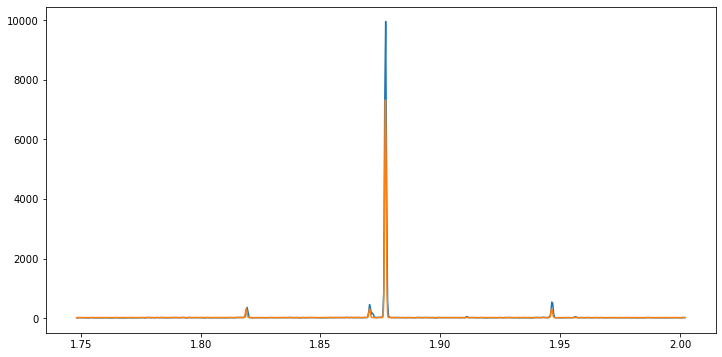

In [9]:
rgrid = np.linspace(1.7482,2.0022,2530)

plt.figure(figsize=(12, 6))
plt.plot(x.value,y.value)
plt.plot(rgrid,Model(rgrid))
plt.show()